# Driving Style Clustering on AV2

Self-contained notebook for the project deliverable: derive driving style from raw AV2 trajectory features, rank features by informativeness, then run K=2 K-means to separate **normal** vs **aggressive** drivers.

Pipeline:
1. Load the per-agent AV2 feature table (built from raw trajectories: speed, accel, jerk, heading-change, curvature, etc.).
2. Apply the project's standard cleaning (`tailrisk_mp.cleaning.filter_for_clustering`) - drops stationary / short-track / non-vehicle / outlier rows.
3. Feature importance: variance, mutual-information vs an aggressiveness proxy, and Random Forest importance. Pick the top features.
4. K=2 K-means on the selected features. Save labels + model.
5. Inspect cluster profiles so the 'aggressive' cluster is interpretable.

Outputs go to `artifacts/clustering/` (separate from the legacy phase1 pipeline).

In [ ]:
from __future__ import annotations
import sys, json, pickle, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_ROOT = REPO_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from tailrisk_mp.cleaning import CleaningConfig, filter_for_clustering

warnings.filterwarnings('ignore', category=FutureWarning)

TABLES = REPO_ROOT / 'artifacts' / 'phase1' / 'tables'
TRAIN_CSV = TABLES / 'av2_train_feature_table.csv'
VAL_CSV   = TABLES / 'av2_val_feature_table.csv'

OUT_DIR = REPO_ROOT / 'artifacts' / 'clustering'
FIG_DIR = OUT_DIR / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
print('Train table:', TRAIN_CSV, '| exists:', TRAIN_CSV.exists())
print('Val table  :', VAL_CSV,   '| exists:', VAL_CSV.exists())
print('Outputs    :', OUT_DIR)

## 1. Load AV2 per-agent feature tables

Each row is one *center agent* in one scenario. Features were extracted from the raw trajectory (`scripts/run_difficulty_analysis.py`). Kinematic columns: speed / acceleration / jerk (avg, max, var, longitudinal, lateral); heading + curvature; event counts (hard brake / hard accel / lateral G spike / high jerk); neighbor / TTC features.

In [ ]:
train_raw = pd.read_csv(TRAIN_CSV)
val_raw   = pd.read_csv(VAL_CSV)
print('train_raw:', train_raw.shape)
print('val_raw  :', val_raw.shape)
train_raw.head(3)

## 2. Pre-cluster cleaning

Drops:
- `is_stationary` rows (parked / idling - no driving style),
- short tracks (< 30 valid future steps),
- non-vehicle agents,
- NaN feature rows,
- percentile-clip outliers (0.1 / 99.9) and Mahalanobis outliers.

Stats are *fit on train* and *applied to val* so val is not contaminated.

In [3]:
cfg_train = CleaningConfig(fit_stats=True)
train_clean, train_report = filter_for_clustering(train_raw, cfg_train,
    report_path=OUT_DIR / 'cleaning_report_train.json')

cfg_val = CleaningConfig(fit_stats=False, reuse_stats=train_report['clean_stats'])
val_clean, val_report = filter_for_clustering(val_raw, cfg_val,
    report_path=OUT_DIR / 'cleaning_report_val.json')

def drop_table(rep):
    rows = [{'reason': k, 'count': v, 'fraction': rep['drop_fractions'][k]}
            for k, v in rep['drop_counts'].items()]
    rows.append({'reason': 'KEPT', 'count': rep['kept_rows'], 'fraction': rep['kept_fraction']})
    return pd.DataFrame(rows)

print('Train  ', train_raw.shape[0], '->', train_clean.shape[0])
print('Val    ', val_raw.shape[0],   '->', val_clean.shape[0])
print('\nTrain drop table:')
print(drop_table(train_report).to_string(index=False))

Train   131673 -> 128369
Val     32987 -> 32161

Train drop table:
                 reason  count  fraction
             stationary   1512  0.011483
            short_track      7  0.000053
            non_vehicle      0  0.000000
            nan_feature      0  0.000000
percentile_clip_outlier    488  0.003706
    outlier_mahalanobis   1297  0.009850
                   KEPT 128369  0.974908


### 2b. Stop-and-go filter

Even after the standard cleaning, agents that spend most of the window stopped and then accelerate (e.g. waiting at a traffic light, then green-light departure) get inflated `*_jerk` / `hard_accel_count` and end up in the aggressive cluster - even though their motion is normal.

We drop those by requiring the agent to be *consistently moving*:

- `avg_speed >= MIN_AVG_SPEED` (default 3.0 m/s) - rules out long-idle windows.
- `avg_speed / max_speed >= MIN_SPEED_RATIO` (default 0.4) - rules out the classic stop-then-go shape, where avg << max.

Both thresholds are reported and easy to tune.

In [4]:
MIN_AVG_SPEED   = 5.0   # m/s (~18 km/h)
MIN_SPEED_RATIO = 0.5   # avg_speed / max_speed - rejects stop-then-go shapes

def drop_stopgo(df, name):
    n0 = len(df)
    speed_ratio = df['avg_speed'] / df['max_speed'].replace(0, np.nan)
    keep = (df['avg_speed'] >= MIN_AVG_SPEED) & (speed_ratio >= MIN_SPEED_RATIO)
    out = df.loc[keep].copy()
    print(f'{name:5s}  {n0} -> {len(out)}  '
          f'(dropped {n0 - len(out)}, {(n0 - len(out)) / max(n0, 1):.1%})')
    return out

train_clean = drop_stopgo(train_clean, 'train')
val_clean   = drop_stopgo(val_clean,   'val')

train  128369 -> 80698  (dropped 47671, 37.1%)
val    32161 -> 20389  (dropped 11772, 36.6%)


### 2c. Physical-sanity filter

Even after stop-and-go cleaning, the feature table contains values that are physically implausible for a road vehicle - they come from finite-difference noise on a stop->go transition or from tracker glitches (e.g. a 200 m/s^3 jerk or a 6 rad/s yaw rate cannot happen on a real car).

Hard upper bounds below come from vehicle-dynamics literature, not data percentiles:

| Feature | Limit | Reason |
|---|---|---|
| `max_speed`              | 40 m/s    | ~145 km/h - faster than any AV2 highway scene |
| `max_abs_accel`          | 12 m/s^2  | ~1.2 g - tire-grip ceiling |
| `max_abs_long_accel`     | 12 m/s^2  | same |
| `max_abs_lat_accel`      | 10 m/s^2  | ~1 g lateral - cornering grip ceiling |
| `max_abs_jerk`           | 50 m/s^3  | ~5 g/s - very aggressive but possible |
| `max_abs_long_jerk`      | 50 m/s^3  | same |
| `max_abs_lat_jerk`       | 50 m/s^3  | same |
| `max_abs_heading_rate`   | 3 rad/s   | ~170 deg/s - cars cannot physically yaw faster |
| `max_abs_heading_delta`  | 1.6 rad   | ~90 deg in one step - anything more is wrap noise |

Tune these by editing `PHYSICAL_LIMITS`. Setting a key to `None` disables that bound.

<Axes: >

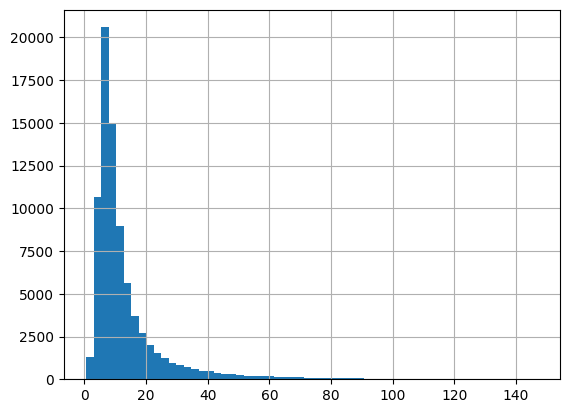

In [6]:
train_clean['max_abs_accel'].hist(bins=60)

In [26]:
# PHYSICAL_LIMITS = {
#     'max_speed':             40.0,   # m/s
#     'max_abs_accel':         12.0,   # m/s^2
#     'max_abs_long_accel':    12.0,
#     'max_abs_lat_accel':     10.0,
#     'max_abs_jerk':          50.0,   # m/s^3
#     'max_abs_long_jerk':     50.0,
#     'max_abs_lat_jerk':      50.0,
#     'max_abs_heading_rate':   3.0,   # rad/s
#     'max_abs_heading_delta':  1.6,   # rad / step
# }

PHYSICAL_LIMITS = {
    'max_speed':             40.0,   # m/s
    'max_abs_accel':         30.0,   # m/s^2
    'max_abs_long_accel':    30.0,
    'max_abs_lat_accel':     20.0,
    'max_abs_jerk':          300.0,   # m/s^3
    'max_abs_long_jerk':     300.0,
    'max_abs_lat_jerk':      300.0,
    'max_abs_heading_rate':   3.0,   # rad/s
    'max_abs_heading_delta':  1.6,   # rad / step
}

def drop_unphysical(df, name, limits=PHYSICAL_LIMITS):
    n0 = len(df)
    keep = pd.Series(True, index=df.index)
    per_feature: list[dict] = []
    for feat, lim in limits.items():
        if lim is None or feat not in df.columns:
            continue
        bad = df[feat].abs() > lim
        per_feature.append({'feature': feat, 'limit': lim,
                            'dropped': int((bad & keep).sum())})
        keep &= ~bad
    out = df.loc[keep].copy()
    print(f'\n{name}  {n0} -> {len(out)}  '
          f'(dropped {n0 - len(out)}, {(n0 - len(out)) / max(n0, 1):.1%})')
    print(pd.DataFrame(per_feature).to_string(index=False))
    return out

train_clean = drop_unphysical(train_clean, 'train')
val_clean   = drop_unphysical(val_clean,   'val')


train  80698 -> 66750  (dropped 13948, 17.3%)
              feature  limit  dropped
            max_speed   40.0        0
        max_abs_accel   30.0     6450
   max_abs_long_accel   30.0        0
    max_abs_lat_accel   20.0      159
         max_abs_jerk  300.0     6912
    max_abs_long_jerk  300.0        0
     max_abs_lat_jerk  300.0        0
 max_abs_heading_rate    3.0      427
max_abs_heading_delta    1.6        0

val  20389 -> 16895  (dropped 3494, 17.1%)
              feature  limit  dropped
            max_speed   40.0        0
        max_abs_accel   30.0     1576
   max_abs_long_accel   30.0        0
    max_abs_lat_accel   20.0       42
         max_abs_jerk  300.0     1756
    max_abs_long_jerk  300.0        0
     max_abs_lat_jerk  300.0        0
 max_abs_heading_rate    3.0      120
max_abs_heading_delta    1.6        0


## 3. Candidate feature pool

All numeric kinematic features that describe *how* an agent moves (no model-side / dataset-bookkeeping columns).
Heading-change-signed is dropped because we want magnitude-based behavior, not turn direction.

In [28]:
# Lateral / braking / steady-state features only.
# Pure longitudinal accel/jerk and hard_accel_count are excluded because a single
# stop->go transient inflates them, even after the stop-and-go cleaning step.
CANDIDATE_FEATURES = [
    # speed (sustained / spread)
    'avg_speed', 'max_speed', 'var_speed',
    # lateral acceleration (cornering load)
    'avg_lat_accel', 'max_abs_lat_accel',
    # lateral jerk (steering aggressiveness)
    'avg_lat_jerk', 'max_abs_lat_jerk',
    # heading & curvature (turn sharpness)
    'heading_change_abs', 'max_abs_heading_delta', 'max_abs_heading_rate',
    'curvature_proxy', 'gamma',
    # braking-only event features (genuine hard braking, NOT green-light starts)
    'hard_brake_count', 'lateral_g_spike_count',
    # path geometry
    'displacement', 'path_length',
]
CANDIDATE_FEATURES = [f for f in CANDIDATE_FEATURES if f in train_clean.columns]
print(len(CANDIDATE_FEATURES), 'candidate features (lateral / braking / steady-state)')

16 candidate features (lateral / braking / steady-state)


## 4. Feature importance

Three complementary scores so we are not relying on one heuristic:

1. **Standardized variance / IQR** - features that are constant give clusters nothing to grip on.
2. **Mutual information vs aggressiveness proxy** - we define a binary proxy from event counts (`hard_brake_count + hard_accel_count + lateral_g_spike_count + high_jerk_count` >= 1) and rank features by MI against it. This is *only* a ranking signal; we do **not** use this proxy as the cluster label.
3. **Random-Forest feature importance** against the same proxy.

Final selection = top-N by an averaged rank across the three scores.

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

X_all = train_clean[CANDIDATE_FEATURES].astype(float).to_numpy()
scaler_all = StandardScaler().fit(X_all)
Xs = scaler_all.transform(X_all)

# 1. variance after standardisation (IQR is more robust)
iqr = np.subtract(*np.percentile(Xs, [75, 25], axis=0))

# 2. aggressiveness proxy: braking + lateral spike events only.
# (hard_accel_count and high_jerk_count are excluded because they fire on green-light starts.)
proxy_event_cols = [c for c in ['hard_brake_count', 'lateral_g_spike_count']
                    if c in train_clean.columns]
y_proxy = (train_clean[proxy_event_cols].sum(axis=1) >= 1).astype(int).to_numpy()
print('Proxy events:', proxy_event_cols, '| positive rate:', y_proxy.mean().round(3))

# subsample for MI / RF speed
rng = np.random.default_rng(RANDOM_STATE)
n_sub = min(15000, len(Xs))
idx = rng.choice(len(Xs), size=n_sub, replace=False)

mi = mutual_info_classif(Xs[idx], y_proxy[idx], random_state=RANDOM_STATE, n_neighbors=5)
rf = RandomForestClassifier(n_estimators=200, max_depth=8, n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(Xs[idx], y_proxy[idx])

imp_df = pd.DataFrame({
    'feature': CANDIDATE_FEATURES,
    'iqr_std': iqr,
    'mutual_info': mi,
    'rf_importance': rf.feature_importances_,
})
for col in ['iqr_std', 'mutual_info', 'rf_importance']:
    imp_df[col + '_rank'] = imp_df[col].rank(ascending=False)
imp_df['avg_rank'] = imp_df[['iqr_std_rank', 'mutual_info_rank', 'rf_importance_rank']].mean(axis=1)
imp_df = imp_df.sort_values('avg_rank').reset_index(drop=True)
imp_df.to_csv(OUT_DIR / 'feature_importance.csv', index=False)
imp_df.head(15)

Proxy events: ['hard_brake_count', 'lateral_g_spike_count'] | positive rate: 0.942


,feature,iqr_std,mutual_info,rf_importance,iqr_std_rank,mutual_info_rank,rf_importance_rank,avg_rank
0,hard_brake_count,1.386590,0.155772,0.461058,2.0,1.0,1.0,1.333333
1,gamma,1.204543,0.097773,0.106158,8.0,2.0,3.0,4.333333
2,max_abs_lat_accel,1.075779,0.083559,0.130931,12.0,3.0,2.0,5.666667
3,heading_change_abs,1.468724,0.040005,0.033903,1.0,8.0,8.0,5.666667
4,max_abs_heading_rate,1.102265,0.044933,0.043439,9.0,6.0,6.0,7.000000
5,max_abs_lat_jerk,1.038945,0.072059,0.060184,13.0,4.0,5.0,7.333333
6,curvature_proxy,1.313660,0.026801,0.015524,5.0,9.0,9.0,7.666667
7,lateral_g_spike_count,0.977357,0.053134,0.091354,14.0,5.0,4.0,7.666667
8,max_abs_heading_delta,1.102265,0.044904,0.034099,10.0,7.0,7.0,8.000000
9,max_speed,1.360410,0.002652,0.001918,3.0,12.0,16.0,10.333333


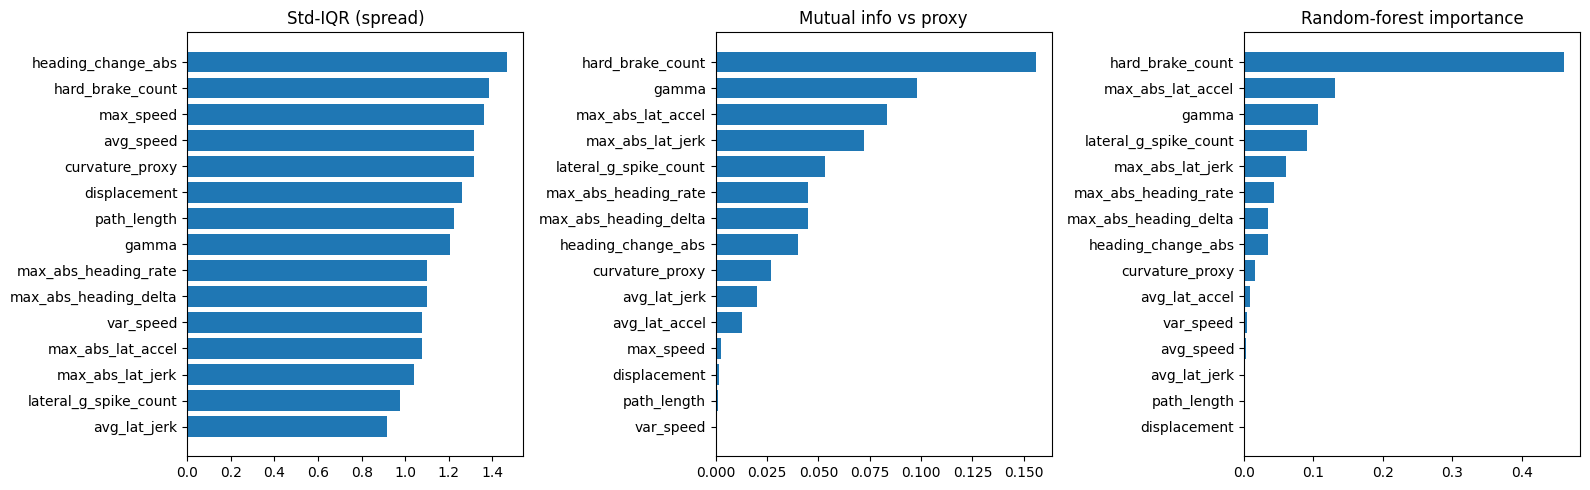

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, title in zip(
    axes,
    ['iqr_std', 'mutual_info', 'rf_importance'],
    ['Std-IQR (spread)', 'Mutual info vs proxy', 'Random-forest importance'],
):
    sub = imp_df.sort_values(col, ascending=True).tail(15)
    ax.barh(sub['feature'], sub[col])
    ax.set_title(title)
fig.tight_layout()
fig.savefig(FIG_DIR / 'feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

### Pick the clustering features

Top-N by averaged rank. Drop near-duplicates (e.g. avg_jerk vs avg_long_jerk) by keeping only the higher-ranked of each correlated pair.

In [9]:
TOP_N = 8
CORR_THRESHOLD = 0.92

ranked = imp_df['feature'].tolist()
selected: list[str] = []
for feat in ranked:
    if len(selected) >= TOP_N:
        break
    keep = True
    if selected:
        corr = train_clean[selected + [feat]].corr().iloc[-1, :-1].abs()
        if (corr > CORR_THRESHOLD).any():
            keep = False
    if keep:
        selected.append(feat)

CLUSTER_FEATURES = selected
print('Selected for clustering:')
for f in CLUSTER_FEATURES:
    print(' -', f)

Selected for clustering:
 - max_abs_lat_accel
 - gamma
 - hard_brake_count
 - max_abs_lat_jerk
 - max_abs_heading_rate
 - lateral_g_spike_count
 - displacement
 - heading_change_abs


In [31]:
TOP_N = 8
CORR_THRESHOLD = 0.92

ranked = imp_df['feature'].tolist()
selected: list[str] = []
for feat in ranked:
    if len(selected) >= TOP_N:
        break
    keep = True
    if selected:
        corr = train_clean[selected + [feat]].corr().iloc[-1, :-1].abs()
        if (corr > CORR_THRESHOLD).any():
            keep = False
    if keep:
        selected.append(feat)

CLUSTER_FEATURES = selected
print('Selected for clustering:')
for f in CLUSTER_FEATURES:
    print(' -', f)

Selected for clustering:
 - hard_brake_count
 - gamma
 - max_abs_lat_accel
 - heading_change_abs
 - max_abs_heading_rate
 - max_abs_lat_jerk
 - lateral_g_spike_count
 - max_speed


## 5. K=2 K-means clustering

Fit `StandardScaler + KMeans(K=2)` on cleaned train, apply to val. The cluster with the higher mean on aggressive-leaning features is labelled `aggressive`.

In [32]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

K = 2

Xtr = train_clean[CLUSTER_FEATURES].astype(float).to_numpy()
Xva = val_clean[CLUSTER_FEATURES].astype(float).to_numpy()

scaler = StandardScaler().fit(Xtr)
Xtr_s = scaler.transform(Xtr)
Xva_s = scaler.transform(Xva)

km = KMeans(n_clusters=K, n_init=20, random_state=RANDOM_STATE).fit(Xtr_s)
tr_lbl = km.labels_
va_lbl = km.predict(Xva_s)

# Label which cluster is aggressive: pick the one with higher mean on lateral / braking signals.
aggressive_signals = [f for f in [
    'max_abs_lat_accel', 'max_abs_lat_jerk', 'lateral_g_spike_count',
    'hard_brake_count', 'max_abs_heading_rate', 'gamma',
] if f in train_clean.columns]
if not aggressive_signals:
    aggressive_signals = CLUSTER_FEATURES[:1]
print('Cluster-labelling signals:', aggressive_signals)

score_per_cluster = (
    train_clean.assign(_c=tr_lbl)
               .groupby('_c')[aggressive_signals]
               .mean()
               .mean(axis=1)
)
agg_cluster = int(score_per_cluster.idxmax())
label_map = {agg_cluster: 'aggressive', 1 - agg_cluster: 'normal'}
print('Cluster -> label:', label_map)

train_clean = train_clean.copy()
val_clean   = val_clean.copy()
train_clean['cluster_id_K2'] = tr_lbl
val_clean['cluster_id_K2']   = va_lbl
train_clean['style_label']   = pd.Series(tr_lbl, index=train_clean.index).map(label_map)
val_clean['style_label']     = pd.Series(va_lbl, index=val_clean.index).map(label_map)

print('\nTrain cluster sizes:')
print(train_clean['style_label'].value_counts())
print('\nVal cluster sizes:')
print(val_clean['style_label'].value_counts())

# internal metrics on a sample (silhouette is O(n^2))
sub = rng.choice(len(Xtr_s), size=min(8000, len(Xtr_s)), replace=False)
metrics = {
    'silhouette': float(silhouette_score(Xtr_s[sub], tr_lbl[sub])),
    'davies_bouldin': float(davies_bouldin_score(Xtr_s, tr_lbl)),
    'calinski_harabasz': float(calinski_harabasz_score(Xtr_s, tr_lbl)),
    'n_train': int(len(tr_lbl)), 'n_val': int(len(va_lbl)),
    'features': CLUSTER_FEATURES, 'label_map': {int(k): v for k, v in label_map.items()},
}
print('\nInternal metrics:', metrics)

with open(OUT_DIR / 'clustering_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
with open(OUT_DIR / 'kmeans_K2.pkl', 'wb') as f:
    pickle.dump({'scaler': scaler, 'model': km, 'features': CLUSTER_FEATURES,
                 'label_map': {int(k): v for k, v in label_map.items()}}, f)

Cluster-labelling signals: ['max_abs_lat_accel', 'max_abs_lat_jerk', 'lateral_g_spike_count', 'hard_brake_count', 'max_abs_heading_rate', 'gamma']
Cluster -> label: {0: 'aggressive', 1: 'normal'}

Train cluster sizes:
style_label
normal        45556
aggressive    21194
Name: count, dtype: int64

Val cluster sizes:
style_label
normal        11545
aggressive     5350
Name: count, dtype: int64

Internal metrics: {'silhouette': 0.3139691304459163, 'davies_bouldin': 1.4171345218904567, 'calinski_harabasz': 27301.96657912629, 'n_train': 66750, 'n_val': 16895, 'features': ['hard_brake_count', 'gamma', 'max_abs_lat_accel', 'heading_change_abs', 'max_abs_heading_rate', 'max_abs_lat_jerk', 'lateral_g_spike_count', 'max_speed'], 'label_map': {0: 'aggressive', 1: 'normal'}}


Cluster-labelling signals: ['max_abs_lat_accel', 'max_abs_lat_jerk', 'lateral_g_spike_count', 'hard_brake_count', 'max_abs_heading_rate', 'gamma']
Cluster -> label: {0: 'aggressive', 1: 'normal'}

Train cluster sizes:
style_label
normal        20185
aggressive     4504
Name: count, dtype: int64

Val cluster sizes:
style_label
normal        10118
aggressive     2269
Name: count, dtype: int64

Internal metrics: {'silhouette': 0.501023916321481, 'davies_bouldin': 1.1284591140365008, 'calinski_harabasz': 12803.1290793034, 'n_train': 24689, 'n_val': 12387, 'features': ['max_abs_lat_accel', 'gamma', 'hard_brake_count', 'max_abs_lat_jerk', 'max_abs_heading_rate', 'lateral_g_spike_count', 'displacement', 'heading_change_abs'], 'label_map': {0: 'aggressive', 1: 'normal'}}

## 6. Cluster profile - is the 'aggressive' cluster actually aggressive?

Per-cluster means on a wider set of behaviour features, normalized to z-scores so we can read which signals dominate.

In [33]:
PROFILE_FEATURES = list(dict.fromkeys(
    CLUSTER_FEATURES + [
        'avg_speed', 'max_speed', 'max_abs_accel', 'max_abs_jerk',
        'hard_brake_count', 'hard_accel_count', 'lateral_g_spike_count', 'high_jerk_count',
        'max_abs_long_accel', 'max_abs_lat_accel', 'gamma',
    ]
))
PROFILE_FEATURES = [f for f in PROFILE_FEATURES if f in train_clean.columns]

z = (train_clean[PROFILE_FEATURES] - train_clean[PROFILE_FEATURES].mean()) / train_clean[PROFILE_FEATURES].std()
z['style_label'] = train_clean['style_label']
profile = z.groupby('style_label')[PROFILE_FEATURES].mean().T
profile['delta'] = profile.get('aggressive', 0) - profile.get('normal', 0)
profile = profile.sort_values('delta', ascending=False)
profile.to_csv(OUT_DIR / 'cluster_profile.csv')
profile.round(3)

style_label,aggressive,normal,delta
heading_change_abs,1.075,-0.500,1.575
lateral_g_spike_count,1.053,-0.490,1.543
max_abs_heading_rate,0.976,-0.454,1.431
max_abs_lat_accel,0.970,-0.451,1.421
max_abs_lat_jerk,0.718,-0.334,1.053
max_abs_accel,0.497,-0.231,0.729
max_abs_jerk,0.451,-0.210,0.661
max_abs_long_accel,0.416,-0.194,0.610
gamma,0.395,-0.184,0.578
hard_accel_count,0.382,-0.178,0.559


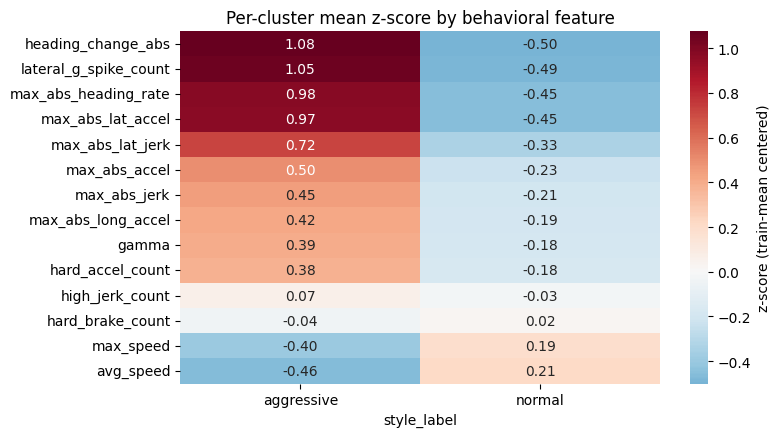

In [34]:
fig, ax = plt.subplots(figsize=(8, max(4, 0.32 * len(PROFILE_FEATURES))))
sns.heatmap(profile.drop(columns='delta'), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax, cbar_kws={'label': 'z-score (train-mean centered)'})
ax.set_title('Per-cluster mean z-score by behavioral feature')
fig.tight_layout()
fig.savefig(FIG_DIR / 'cluster_profile_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

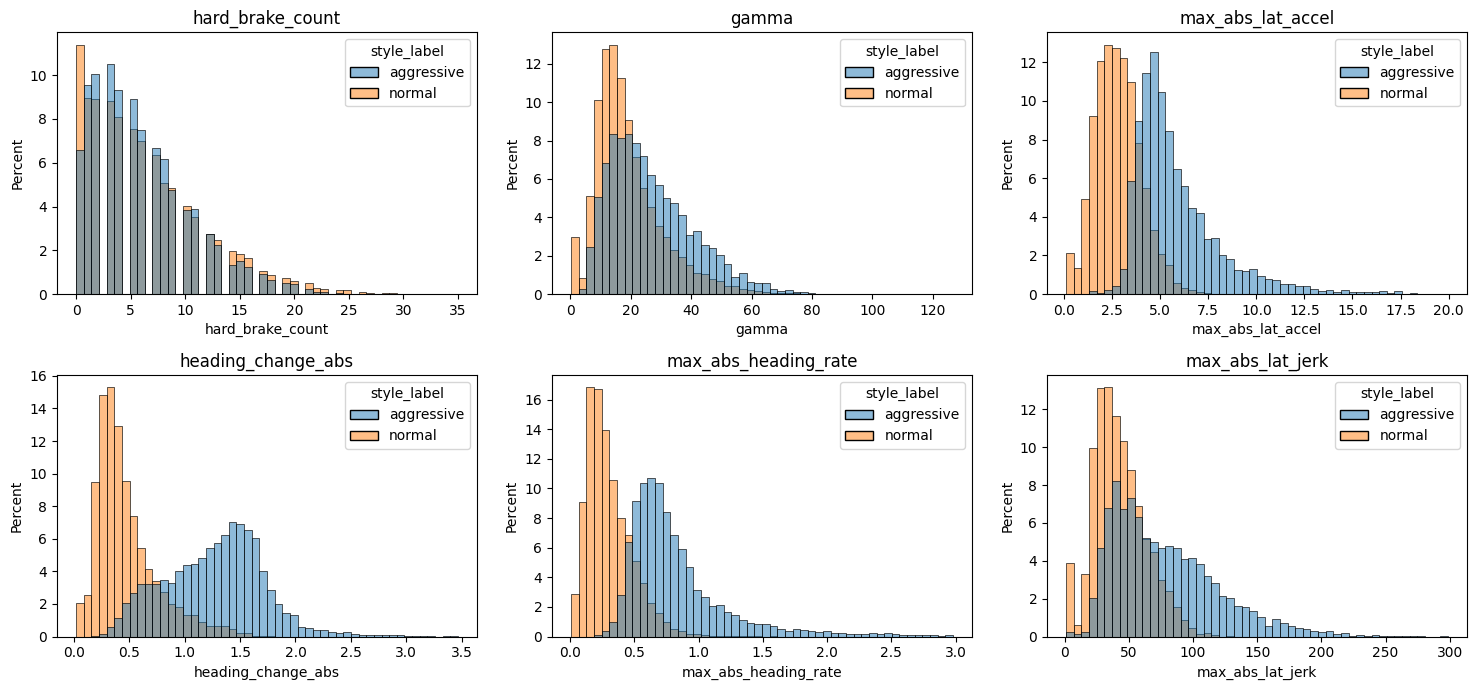

In [36]:
# Quick visual: kinematic distributions per cluster (val)
n_show = min(6, len(CLUSTER_FEATURES))
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, feat in zip(axes.flat, CLUSTER_FEATURES[:n_show]):
    sns.histplot(data=val_clean, x=feat, hue='style_label', stat='percent',
                 common_norm=False, bins=50, ax=ax)
    ax.set_title(feat)
for ax in axes.flat[n_show:]:
    ax.set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / 'cluster_distributions_val.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Save labelled tables

These parquets are the input to the GIF notebook (`driving_style_gifs.ipynb`).

In [ ]:
train_clean.to_parquet(OUT_DIR / 'av2_train_clustered.parquet', index=False)
val_clean.to_parquet(OUT_DIR / 'av2_val_clustered.parquet', index=False)
print('Wrote:')
for p in OUT_DIR.glob('*'):
    print(' ', p.relative_to(REPO_ROOT))